In [1]:
import os
import anndata
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import torch
import scvi
import json
import pandas as pd

# ----------------- paths / settings -----------------
DATA_DIR = "../data_centralized"
TEST_PATH  = os.path.join(DATA_DIR, "pancreas_test.h5ad")
HVG_PATH   = os.path.join(DATA_DIR, "top2k_genes.json")
TECHS_PATH = os.path.join(DATA_DIR, "all_techs.json")
FEDERATED_STATE_DICT = os.path.join("../model_federated", "model.pt")
CENTRALIZED_FOLDER = os.path.join("../model_centralized")

/opt/miniconda3/envs/fl-course-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load hvg list
with open(HVG_PATH) as f: hvg_list = json.load(f)

# load techs list
with open(TECHS_PATH) as f: all_techs = json.load(f)

# load test data
adata_test = anndata.read_h5ad(TEST_PATH)
adata_test = adata_test[:, hvg_list].copy()


## Batch effects in original gene expression

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


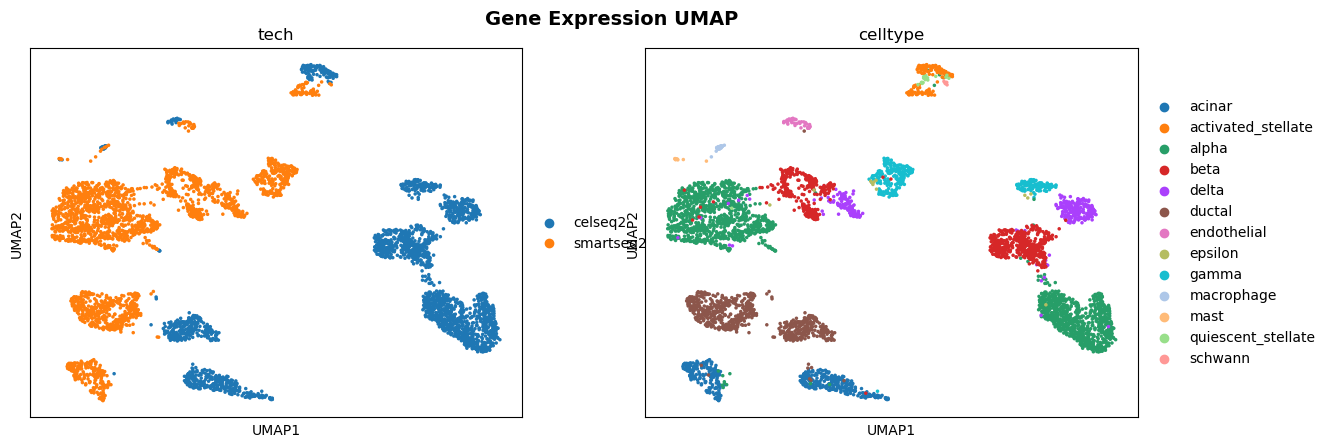

In [3]:
# Set raw counts as the working matrix
adata_test.X = adata_test.layers["counts"].copy()

# Basic preprocessing on expression for plotting
sc.pp.normalize_total(adata_test, target_sum=1e4)
sc.pp.log1p(adata_test)
sc.pp.scale(adata_test, max_value=10) 

# Dimensionality reduction and UMAP
sc.tl.pca(adata_test, n_comps=50)
sc.pp.neighbors(adata_test, n_pcs=50)
sc.tl.umap(adata_test)

sc.pl.umap(adata_test, color=["tech", "celltype"], show=False)
plt.suptitle("Gene Expression UMAP", fontsize=14, fontweight="bold")
plt.show()

## Batch effects in latent representation using centralized model

INFO     File ../model_centralized/model.pt already downloaded                                                     
INFO     Found 100.0% reference vars in query data.                                                                
INFO     File ../model_centralized/model.pt already downloaded                                                     


/opt/miniconda3/envs/fl-course-env/lib/python3.11/site-packages/scvi/model/base/_archesmixin.py:105: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  _, _, device = parse_device_args(
/opt/miniconda3/envs/fl-course-env/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/opt/miniconda3/envs/fl-course-env/lib/python3.11/site-packages/scvi/train/_trainrunner.py:69: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = 

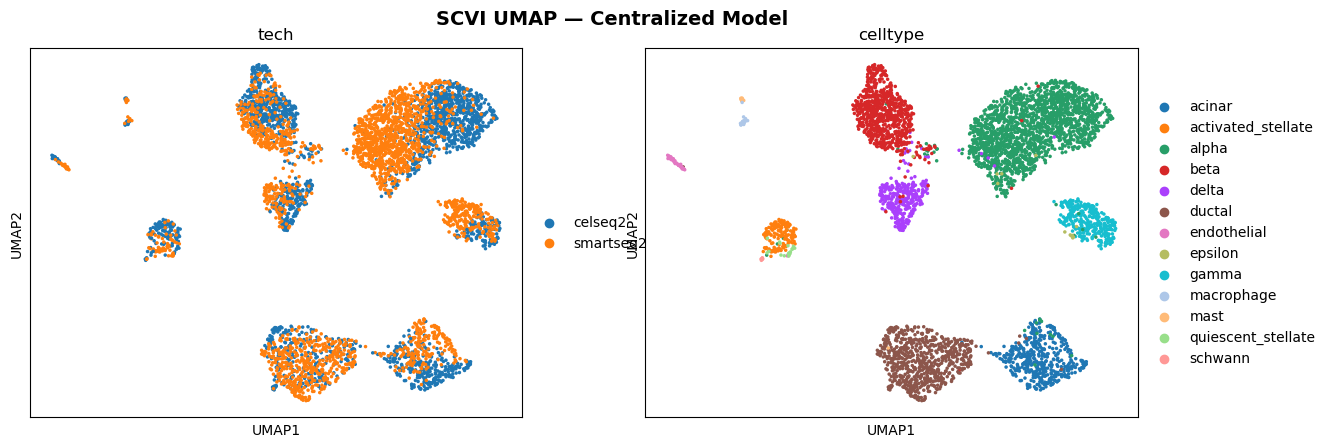

In [4]:
scvi.model.SCVI.prepare_query_anndata(adata_test, CENTRALIZED_FOLDER)
scvi_test = scvi.model.SCVI.load_query_data(adata_test, CENTRALIZED_FOLDER)

scvi_test.train(max_epochs=0, plan_kwargs={"weight_decay": 0.0})
adata_test.obsm["X_scVI_centralized"] = scvi_test.get_latent_representation()

# Neighbors/UMAP on the scVI latents
sc.pp.neighbors(adata_test, use_rep="X_scVI_centralized")
sc.tl.leiden(adata_test)
sc.tl.umap(adata_test)

sc.pl.umap(adata_test, color=["tech", "celltype"], show=False)
plt.suptitle("SCVI UMAP — Centralized Model", fontsize=14, fontweight="bold")
plt.show()

## Batch effects in latent representation using federated model

/opt/miniconda3/envs/fl-course-env/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


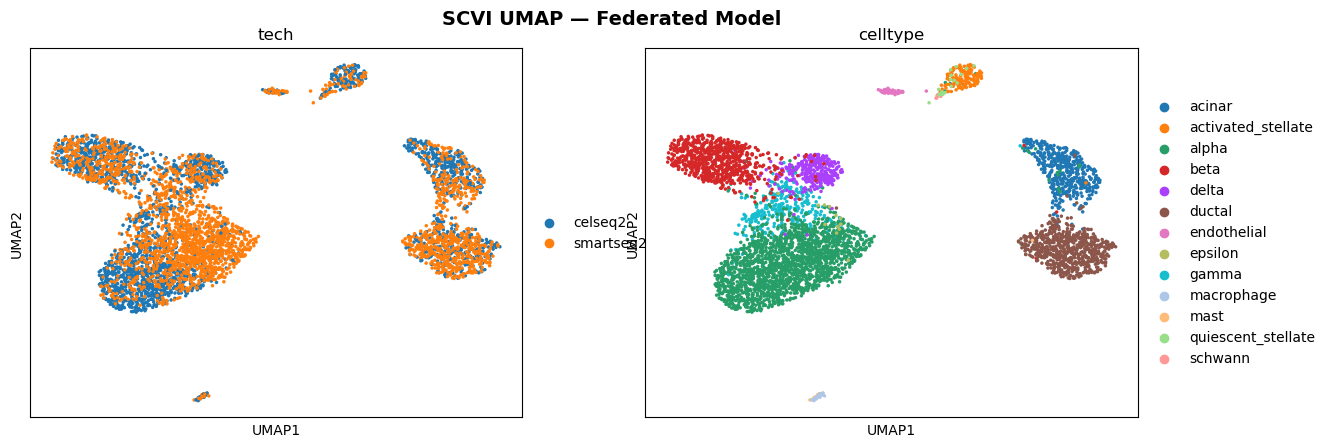

In [5]:
import anndata
import pandas as pd
import torch
import scanpy as sc
import matplotlib.pyplot as plt
import scvi

def load_federated_scvi_model(adata, ckpt, all_techs):
    adata.obs["tech"] = pd.Categorical(adata.obs["tech"], categories=all_techs)

    scvi.model.SCVI.setup_anndata(adata, batch_key="tech", layer="counts")

    model = scvi.model.SCVI(
        adata,
        use_layer_norm="both",
        use_batch_norm="none",
        encode_covariates=True,
        dropout_rate=0.2,
        n_layers=2,
    )

    state = {
        k: v for k, v in ckpt["model_state_dict"].items()
        if k != "pyro_param_store"
    }

    model.module.load_state_dict(state)
    model.is_trained = True
    return model


ckpt = torch.load(FEDERATED_STATE_DICT, map_location="cpu", weights_only=False)

adata_test = anndata.read_h5ad(TEST_PATH)
adata_test = adata_test[:, hvg_list].copy()

scvi_model = load_federated_scvi_model(adata_test, ckpt, all_techs)

with torch.inference_mode():
    adata_test.obsm["X_scVI_federated"] = scvi_model.get_latent_representation()

sc.pp.neighbors(adata_test, use_rep="X_scVI_federated")
sc.tl.leiden(adata_test)
sc.tl.umap(adata_test)

adata_test.obs["tech"] = adata_test.obs["tech"].cat.remove_unused_categories()

sc.pl.umap(adata_test, color=["tech", "celltype"], show=False)
plt.suptitle("SCVI UMAP — Federated Model", fontsize=14, fontweight="bold")
plt.show()